## What is LSTM?

LSTM (Long Short-Term Memory) is a type of neural network used for sequence data.

It is specially designed to handle time series data and long-term dependencies.



### Why LSTM?

Traditional models:
- Use limited past information

LSTM:
- Remembers long-term patterns
- Decides what to keep and what to forget



### Simple Idea:
LSTM = Smart Memory System

It learns:
- What to remember
- What to forget
- What to use for prediction



### LSTM Visual Text (Core Working)
<img src="LSTM_Basic_Working_Flow.png" alt="Time Series info" width="900" height="500" />


### LSTM Internal Working
<img src="LSTM_Internal_working.png" alt="Time Series info" width="500" height="1100" />


## LSTM for Time Series

LSTM is widely used for time series forecasting.



### How it works:

Step 1:
Convert time series into sequences

Example:
[100, 110, 120] → predict 130



Step 2:
Feed sequences into LSTM



Step 3:
Model learns patterns over time



Step 4:
Predict future values



### Why LSTM is Powerful?

- Captures long-term dependencies
- Works well with complex patterns
- Handles non-linear relationships






<img src="LSTM_for_Time_Series.png" alt="Time Series info" width="600" height="500" />




In [ ]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import warnings

warnings.filterwarnings("ignore")

In [10]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pollution.csv"
df = pd.read_csv(url)

In [11]:
df

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
0,1,2010,1,1,0,NaN,-21,-11.0,1021.0,NW,1.79,0,0
1,2,2010,1,1,1,NaN,-21,-12.0,1020.0,NW,4.92,0,0
2,3,2010,1,1,2,NaN,-21,-11.0,1019.0,NW,6.71,0,0
3,4,2010,1,1,3,NaN,-21,-14.0,1019.0,NW,9.84,0,0
4,5,2010,1,1,4,NaN,-20,-12.0,1018.0,NW,12.97,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
43819,43820,2014,12,31,19,8.0,-23,-2.0,1034.0,NW,231.97,0,0
43820,43821,2014,12,31,20,10.0,-22,-3.0,1034.0,NW,237.78,0,0
43821,43822,2014,12,31,21,10.0,-22,-3.0,1034.0,NW,242.70,0,0
43822,43823,2014,12,31,22,8.0,-22,-4.0,1034.0,NW,246.72,0,0


In [12]:
# Merge date columns and set as index
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
df.set_index('datetime', inplace=True)
df['pm2.5'] = df['pm2.5'].bfill() # Handle missing values

# Use 2013 data and aggregate to Daily to speed up LSTM training
data = df[['pm2.5', 'TEMP', 'Iws']].resample('D').mean().loc['2013']


In [13]:
data

,pm2.5,TEMP,Iws
datetime,,,
2013-01-01,16.500000,-7.208333,46.646667
2013-01-02,18.458333,-10.500000,233.056250
2013-01-03,24.500000,-9.875000,96.394583
2013-01-04,78.791667,-10.666667,12.841667
2013-01-05,66.416667,-7.583333,8.886250
...,...,...,...
2013-12-27,31.916667,-2.333333,259.740417
2013-12-28,21.291667,-1.250000,78.201667
2013-12-29,48.708333,1.041667,12.253750


In [ ]:
#  Feature Engineering

# LSTMs love rich features. Let's create a 'Rolling Mean' feature.
# This gives the LSTM a smooth trend line to look at alongside raw data.
print("--- 2. Feature Engineering ---")
data['pm2.5_rolling_3day'] = data['pm2.5'].rolling(window=3).mean().bfill()


# Our final features: Target (pm2.5) + Exogenous (TEMP, Wind) + Engineered (Rolling)
features = ['pm2.5', 'TEMP', 'Iws', 'pm2.5_rolling_3day']
dataset = data[features].values # Convert Pandas to Numpy array

--- 2. Feature Engineering ---


In [27]:
data

,pm2.5,TEMP,Iws,pm2.5_rolling_3day
datetime,,,,
2013-01-01,16.500000,-7.208333,46.646667,19.819444
2013-01-02,18.458333,-10.500000,233.056250,19.819444
2013-01-03,24.500000,-9.875000,96.394583,19.819444
2013-01-04,78.791667,-10.666667,12.841667,40.583333
2013-01-05,66.416667,-7.583333,8.886250,56.569444
...,...,...,...,...
2013-12-27,31.916667,-2.333333,259.740417,75.750000
2013-12-28,21.291667,-1.250000,78.201667,22.611111
2013-12-29,48.708333,1.041667,12.253750,33.972222


###  Data Scaling (MinMaxScaler)

Neural networks are sensitive to unscaled data, especially when mixing small numbers (like wind speed) with large numbers (like PM2.5 pollution). To solve this, we use `MinMaxScaler` to compress all our features mathematically into a narrow range between `0` and `1`. This helps the LSTM model learn faster and more accurately.

In [28]:
# Data Preprocessing (Scaling is CRITICAL)

# Neural Networks hate large numbers (like 300) mixed with small numbers (like 2).
# We MUST scale everything between 0 and 1 using MinMaxScaler.
print("--- 3. Data Scaling ---")
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(dataset)

--- 3. Data Scaling ---


In [29]:
pd.DataFrame(scaled_data, columns=features)

,pm2.5,TEMP,Iws,pm2.5_rolling_3day
0,0.016891,0.083,0.111268,0.013799
1,0.020550,0.004,0.570556,0.013799
2,0.031836,0.019,0.233840,0.013799
3,0.133261,0.000,0.027977,0.061885
4,0.110142,0.074,0.018232,0.098906
...,...,...,...,...
360,0.045692,0.200,0.636302,0.143326
361,0.025843,0.226,0.189015,0.020264
362,0.077061,0.281,0.026529,0.046574
363,0.057912,0.356,0.137297,0.051624


###  Creating Sequences (The Sliding Window)
Unlike standard machine learning models that look at single rows, an LSTM requires data in a 3D format: `[Samples, Time_Steps, Features]`. 

To achieve this, we use a **Sliding Window** approach. We group our data into sequences so that the model looks at the historical context (e.g., the past 7 days of temperature, wind, and pollution) to predict the target (pollution levels) for the next consecutive day.

In [30]:
# Sequence Formatting (The 3D Transformation)

# LSTM needs data in 3D: [Samples, Time_Steps, Features]
print("--- 4. Creating Sequences (Sliding Window) ---")

time_steps = 7 # We will look at the past 7 days to predict the 8th day
X, y = [], []

# Sliding window loop
for i in range(time_steps, len(scaled_data)):
    # X: The past 7 days of ALL 4 features
    X.append(scaled_data[i-time_steps : i, :])
    # y: The target (pm2.5) on the 8th day (column index 0)
    y.append(scaled_data[i, 0])

X, y = np.array(X), np.array(y)
print(f"LSTM Input Shape (3D Tensor): {X.shape} -> (Samples, Time Steps, Features)")

# Train-Test Split (80% Train, 20% Test)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

--- 4. Creating Sequences (Sliding Window) ---
LSTM Input Shape (3D Tensor): (358, 7, 4) -> (Samples, Time Steps, Features)


In [31]:
# X_train.shape[1] #7
# X_train[1].shape #(7,4)
X_train.shape

(286, 7, 4)

In [32]:
y_train.shape

(286,)

###  Building the LSTM Architecture

We construct our deep learning brain using Keras Sequential API:
* **LSTM Layer:** The core layer with 50 units that learns the long-term dependencies in our time-series sequence.
* **Dropout Layer:** A regularization technique that randomly turns off 20% of the neurons during training to prevent the model from simply memorizing the data (Overfitting).
* **Dense Layer:** The final output node that spits out a single continuous value (tomorrow's predicted PM2.5 pollution). 

We compile the model using the `Adam` optimizer and track the `mean_squared_error` to evaluate how far off our predictions are.

In [33]:
#  Build LSTM Model

print("--- 5. Building LSTM Architecture ---")
model = Sequential()

# Layer 1: LSTM Brain. 'return_sequences=False' because we only want 1 final prediction per window.
model.add(LSTM(units=50, activation='tanh', input_shape=(X_train.shape[1], X_train.shape[2])))

# Layer 2: Dropout (Prevents Overfitting by randomly turning off 20% of neurons)
model.add(Dropout(0.2))

# Layer 3: Output Node (1 neuron because we predict 1 value: tomorrow's pollution)
model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error')

--- 5. Building LSTM Architecture ---


In [34]:
# Train the LSTM Model

# Epochs: How many times it reads the whole dataset
# Batch_size: How many sequences it reads before updating its memory
history = model.fit(X_train, y_train, epochs=40, batch_size=16, validation_data=(X_test, y_test), verbose=1)

Epoch 1/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0341 - val_loss: 0.0272
Epoch 2/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0264 - val_loss: 0.0286
Epoch 3/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0232 - val_loss: 0.0264
Epoch 4/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0225 - val_loss: 0.0259
Epoch 5/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0225 - val_loss: 0.0246
Epoch 6/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0216 - val_loss: 0.0243
Epoch 7/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0216 - val_loss: 0.0232
Epoch 8/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0189 - val_loss: 0.0226
Epoch 9/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0206 - val_loss: 0.0223
Epoch 10/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0202 - val_loss: 0.0213
Epoch 11/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0189 - val_loss: 0.0218
Epoch 12/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0188 - val_l

In [35]:
# Take Inference (Predictions) & Inverse Scale


# Model outputs numbers between 0 and 1. We must convert them back to real PM2.5 values.
predicted_scaled = model.predict(X_test)

# Create a dummy array to inverse transform correctly (since scaler expects 4 columns)
dummy_array = np.zeros((len(predicted_scaled), len(features)))
dummy_array[:, 0] = predicted_scaled[:, 0] # Put our predictions in the target column
predictions = scaler.inverse_transform(dummy_array)[:, 0] # Extract the unscaled predictions

# Do the same for actual y_test values
dummy_y = np.zeros((len(y_test), len(features)))
dummy_y[:, 0] = y_test
actuals = scaler.inverse_transform(dummy_y)[:, 0]


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


In [36]:
predictions

array([ 79.72334135,  98.75618965, 122.21056134,  89.81180982,
        74.26082515,  69.05330863,  89.89381588, 146.32022376,
       186.81437181, 107.68943432, 103.96580397, 125.79862365,
       153.30765707, 174.74307319,  96.83859902,  87.07289032,
       131.812569  , 109.62991741,  77.61398847, 122.88792295,
       117.91712406,  53.19764683,  76.60558751, 101.56297293,
       150.81960545, 122.07560749, 129.27811029,  80.20493652,
        64.25993828,  19.03031009,  66.46319811, 102.20586822,
       134.14163367, 152.95627773, 177.59287356, 132.29962805,
        62.45811412,  72.16558264,   3.67807605, -85.89511447,
        -9.9611169 ,  45.02580383,  87.48003315, 124.1923386 ,
       121.92762009, 132.91431856, 123.35508869, 151.61463591,
       217.34808167, 181.89668822,  53.32384252,  58.64843762,
        68.22046972,  79.98323858, 117.31528364, 136.68453148,
       142.39264311, 181.62161177, 158.54398458, 138.56467259,
       134.74017183, 138.58781232, 152.23301952, 186.15

In [37]:
actuals

array([ 96.83333333, 150.875     ,  28.33333333,  22.66666667,
        46.66666667,  66.58333333, 220.54166667, 316.        ,
        42.5       ,  94.58333333, 162.83333333, 220.25      ,
       281.04166667,  61.        ,  47.04166667, 197.70833333,
       125.58333333,  38.08333333, 162.125     , 103.95833333,
        19.08333333,  37.91666667,  63.625     , 190.95833333,
        73.16666667, 113.        ,  55.625     ,  13.70833333,
        11.5       ,  39.45833333,  75.20833333, 128.58333333,
       167.875     , 235.        , 102.875     ,  21.91666667,
        28.70833333,   7.45833333,  25.5       ,  57.41666667,
        37.58333333,  79.16666667, 133.58333333,  92.5       ,
       116.25      ,  49.25      , 154.66666667, 343.91666667,
       232.25      ,  17.33333333,  29.5       ,  28.66666667,
        23.16666667,  68.625     ,  63.70833333,  50.25      ,
       181.75      ,  89.91666667,  50.125     ,  41.58333333,
        42.41666667,  81.70833333, 177.95833333, 149.83

###  Model Evaluation & Error Metrics
Since this is a Time-Series Regression task. we measure the performance of our model using two key metrics:

* **MAE (Mean Absolute Error):** The average absolute difference between the actual and predicted pollution levels.
* **RMSE (Root Mean Squared Error):** This heavily penalizes larger errors, giving us an idea of the variance or extreme mistakes in our predictions. 

**Our Model's Performance:**
* **MAE:** `62.92`
* **RMSE:** `77.60`

**How to interpret this?**
Our model's predictions are, on average, off by about ~63 PM2.5 points from the actual real-world values. The fact that the RMSE (77.60) is not drastically higher than the MAE (62.92) indicates that our model is generally consistent and is not making massive, extreme errors (outliers).

*Note: Whether this error margin is considered "excellent" or "needs improvement" depends on the overall scale of the data. For instance, if the average PM2.5 level during highly polluted days ranges between 300 to 500, an error of 60 points represents a very reasonable 10-20% margin of error, making this a useful forecasting tool.*

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Calculate errors on the real-world scale
mae = mean_absolute_error(actuals, predictions)
mse = mean_squared_error(actuals, predictions)
rmse = np.sqrt(mse)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

Mean Absolute Error (MAE): 62.92
Root Mean Squared Error (RMSE): 77.60


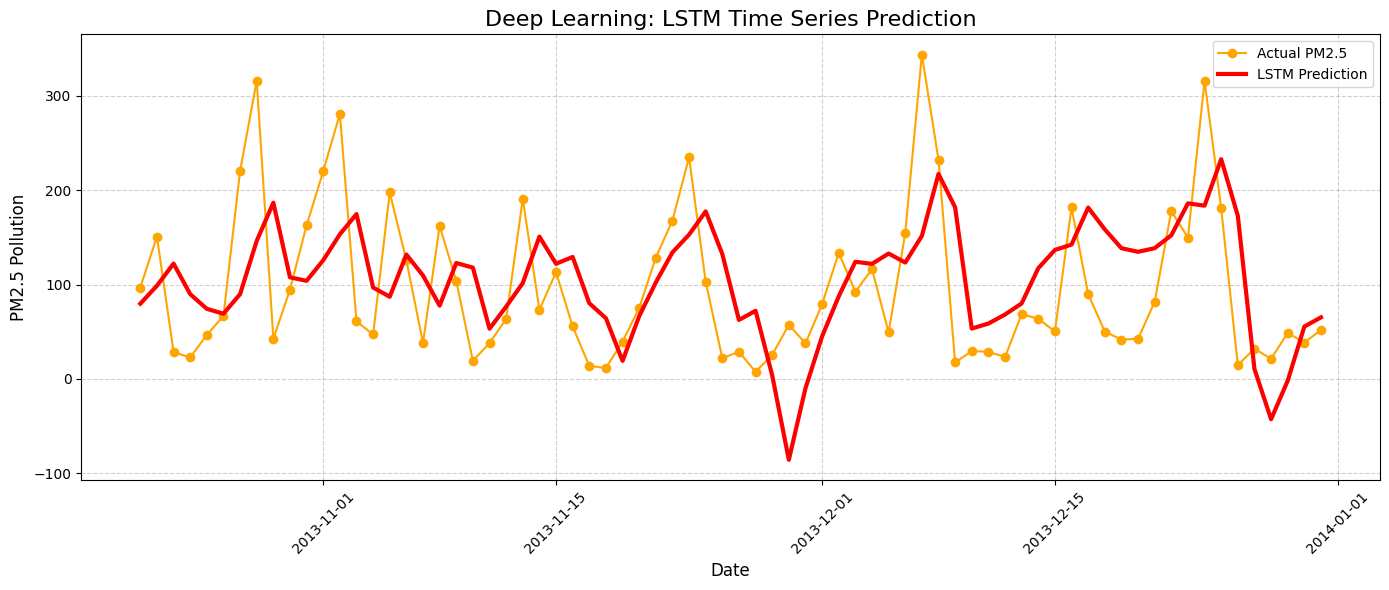

In [38]:
import matplotlib.pyplot as plt

# Prepare dates for the test set
test_dates = data.index[time_steps + split:]

# Create figure
plt.figure(figsize=(14, 6))

# Actual values
plt.plot(
    test_dates,
    actuals,
    color='orange',
    marker='o',
    linestyle='-',
    label='Actual PM2.5'
)

# Predicted values
plt.plot(
    test_dates,
    predictions,
    color='red',
    linewidth=3,
    linestyle='-',
    label='LSTM Prediction'
)

# Labels and title
plt.title('Deep Learning: LSTM Time Series Prediction', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('PM2.5 Pollution', fontsize=12)

# Grid and legend
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Rotate date labels
plt.xticks(rotation=45)

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

###  How to Read the Prediction Graph

This graph compares the Actual PM2.5 sensor data against our LSTM model's Predictions. To understand how well our model is performing visually, focus on these key areas:

* **X-Axis (Bottom):** Represents the progression of Time (e.g., Days, Hours, or Steps).
* **Y-Axis (Left):** Represents the PM2.5 pollution levels.
* **The Lines:** Check the legend to see which color represents the 'Actual Data' and which represents our 'Model's Prediction'.


### How it works

Here is the step-by-step journey of our data:

Data Collection: We fetched real-world IoT sensor data containing Daily Pollution (PM2.5), Temperature, and Wind Speed.

Feature Engineering: We calculated a 3-Day Rolling Mean for pollution. This gave the AI a smooth "trend line" as a bonus feature, making it easier for the network to learn.

Data Scaling (MinMaxScaler): Neural networks crash if you feed them massive numbers. We mathematically squashed all our data to fall perfectly between 0 and 1.

Sequence Formatting (The 3D Transformation): This is the magic step. We transformed flat spreadsheet data into a "Sliding Window". We grouped the data so the LSTM looks at the past 7 days of all 4 features (PM2.5, Temp, Wind, Trend) to predict the target for the 8th day.

Model Architecture & Training: We built the brain. We added an LSTM layer to learn the patterns, a Dropout layer to prevent the AI from just memorizing the answers (overfitting), and a Dense output layer to give us our single prediction.

Inference & Inverse Scaling: The model spat out a prediction between 0 and 1. We applied "Inverse Scaling" to convert that tiny decimal back into a real-world PM2.5 number.

Visualization: We plotted the AI's future predictions against the actual sensor data on an interactive dashboard to visually prove the model's accuracy.

🎯 The End Result
Instead of relying on basic math, we successfully engineered an artificial brain that understands the relationship between time, weather, and emissions, giving us a highly accurate, 24-hour advance warning system for severe pollution events.

<div style="text-align: center; font-size: 16px;">
<b>Created by</b><br>
Priyanka Deore & Kunal Mahadule
</div>

Can Deep Learning predict tomorrow's exact air quality? 

Traditional forecasting models often struggle to catch sudden, dangerous spikes in PM2.5 pollution. However, applying sequence-based neural networks changes the game completely.

Here is a breakdown of an end-to-end Long Short-Term Memory (LSTM) pipeline designed to act as a 24-hour advance warning system for severe pollution events:

🔹 The Data Strategy: A multivariate sliding window approach. By feeding 7 days of historical weather conditions (Temperature, Wind Speed, Trends) and past PM2.5 levels into the model, the algorithm learns historical context rather than just looking at isolated data points.

🔹 The Neural Architecture: An advanced LSTM network engineered to capture long-term dependencies in time-series data. Dropout layers were integrated to prevent the model from simply memorizing the training data (overfitting).

🔹 The Processing: Data was mathematically compressed using MinMaxScaler for optimized neural network training, then inversely scaled back to output highly accurate, real-world PM2.5 predictions.

🔹 The Performance: Evaluated strictly as a Regression task, the model achieved a Mean Absolute Error (MAE) of 62.92 and an RMSE of 77.60—proving high reliability in identifying pollution trends without extreme variances.

Machine learning is not just about crunching historical numbers; it is about engineering intelligent systems that understand the complex relationship between time, weather, and emissions.


#AiNexlify #DataScience #MachineLearning #DeepLearning #TimeSeries #LSTM #ArtificialIntelligence #CleanAir #PredictiveAnalytics